<a href="https://colab.research.google.com/github/San0160/Image-segmentaion/blob/main/Image_segmentaion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Importing relevant modules.

import random
import numpy as np
import matplotlib.pyplot as plt
from pycocotools.coco import COCO  # API for COCO dataset.
import skimage.io as io

import torch
import cv2
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

%matplotlib inline

In [48]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [3]:
# Import and mount Google Drive.

from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Unzip the dataset file and store it in a folder called images.

!unzip "/content/drive/MyDrive/RMDS_segmentation_dataset_ADE20K_350.zip" -d "/content/drive/MyDrive/ADE20K/"

Archive:  /content/drive/MyDrive/RMDS_segmentation_dataset_ADE20K_350.zip


In [4]:
# Define location of training data (images and labels).

train_data_path = "/content/drive/MyDrive/ADE20K/train"
train_annotation_file = "/content/drive/MyDrive/ADE20K/instances_train.json"

In [5]:
# Initialising COCO API for instance annotations.

coco = COCO(train_annotation_file)

loading annotations into memory...
Done (t=0.03s)
creating index...
index created!


In [6]:
# Extract and display COCO categories and supercategories for the training dataset.

category_IDs = coco.getCatIds()
categories = coco.loadCats(category_IDs)

print(categories)

names_cats = [cats["name"] for cats in categories]
print(len(names_cats), "COCO categories:", " ".join(names_cats))

[{'id': 1, 'name': 'bed'}, {'id': 2, 'name': 'windowpane'}, {'id': 3, 'name': 'cabinet'}, {'id': 4, 'name': 'person'}, {'id': 5, 'name': 'door'}, {'id': 6, 'name': 'table'}, {'id': 7, 'name': 'curtain'}, {'id': 8, 'name': 'chair'}, {'id': 9, 'name': 'car'}, {'id': 10, 'name': 'painting'}, {'id': 11, 'name': 'sofa'}, {'id': 12, 'name': 'shelf'}, {'id': 13, 'name': 'mirror'}, {'id': 14, 'name': 'armchair'}, {'id': 15, 'name': 'seat'}, {'id': 16, 'name': 'fence'}, {'id': 17, 'name': 'desk'}, {'id': 18, 'name': 'wardrobe'}, {'id': 19, 'name': 'lamp'}, {'id': 20, 'name': 'bathtub'}, {'id': 21, 'name': 'railing'}, {'id': 22, 'name': 'cushion'}, {'id': 23, 'name': 'box'}, {'id': 24, 'name': 'column'}, {'id': 25, 'name': 'signboard'}, {'id': 26, 'name': 'chest of drawers'}, {'id': 27, 'name': 'counter'}, {'id': 28, 'name': 'sink'}, {'id': 29, 'name': 'fireplace'}, {'id': 30, 'name': 'refrigerator'}, {'id': 31, 'name': 'stairs'}, {'id': 32, 'name': 'case'}, {'id': 33, 'name': 'pool table'}, {'i

In [7]:
# Define function to extract category name from ID.

def get_category_name(class_ID, categories):
    for i in range(len(categories)):
        if categories[i]["id"] == class_ID:
            return categories[i]["name"]
    return "None"

In [8]:
# Look at one example.

category_name_10 = get_category_name(10, categories)
print(f"The category name is {category_name_10}.")

# Make sure to check out some others.

The category name is painting.


In [9]:
# Get all training images containing a given object category or categories.

filter_class = ["airplane", "car", "book", "person"]
category_IDs = coco.getCatIds(catNms=filter_class)

# Collect image IDs for each category and then combine them to get unique IDs
all_image_ids = set()
for cat_id in category_IDs:
    img_ids_for_cat = coco.getImgIds(catIds=[cat_id])
    all_image_ids.update(img_ids_for_cat)

image_IDs = list(all_image_ids)

print(f"Number of images containing specified category(ies): {len(image_IDs)}.")
print(f"IDs of images containing specified category(ies): {image_IDs}.")

# What happens when you are filtering for a different category or multiple classes?

Number of images containing specified category(ies): 350.
IDs of images containing specified category(ies): [20500, 20502, 20513, 20515, 20540, 20554, 20556, 20575, 20579, 20585, 20589, 20590, 20591, 20596, 20600, 20614, 20616, 20618, 20624, 20626, 20630, 20633, 20642, 20647, 20649, 20651, 20690, 20699, 20702, 20705, 20709, 20711, 20712, 20720, 20728, 20729, 20730, 20737, 20741, 20748, 20766, 20772, 20773, 20781, 20782, 20785, 20789, 20792, 20793, 20799, 20809, 20816, 20818, 20819, 20820, 20824, 20828, 20829, 20830, 20832, 20836, 20842, 20847, 20854, 20855, 20857, 20859, 20860, 20865, 20874, 20881, 20887, 20890, 20903, 20909, 20924, 20925, 20934, 20937, 20943, 20944, 20945, 20952, 20953, 20957, 20958, 20962, 20977, 20988, 20994, 20995, 20996, 20997, 20998, 21000, 21002, 21005, 21007, 21010, 21014, 21015, 21017, 21018, 21022, 21023, 21026, 21027, 21028, 21032, 21036, 21037, 21039, 21040, 21042, 21044, 21045, 21046, 21050, 21051, 21056, 21057, 21061, 21065, 21066, 21067, 21071, 21072, 21

{'file_name': 'ADE_val_00001864.jpg', 'width': 256, 'id': 22073, 'height': 256}


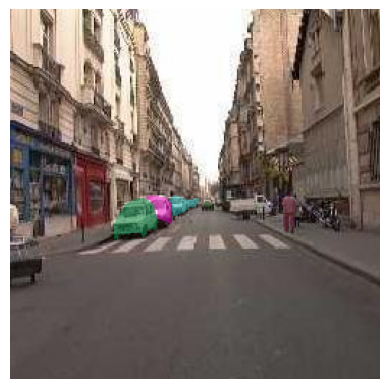

In [10]:
# Load and display example training image with segmentation masks.

# Re-defining target_classes and related variables as the previous cells were deleted.
target_classes = ["person", "car", "book", "airplane"]
target_classes_IDs = coco.getCatIds(catNms=target_classes)

training_images = []
for class_name in target_classes:
    training_images_categories = coco.getCatIds(catNms=class_name)
    training_images_IDs = coco.getImgIds(catIds=training_images_categories)
    training_images += coco.loadImgs(training_images_IDs)

unique_training_images = []
for i in range(len(training_images)):
    if training_images[i] not in unique_training_images:
        unique_training_images.append(training_images[i])

import random
random.seed(0)
random.shuffle(unique_training_images)


training_image = unique_training_images[50]
print(training_image)

image = io.imread(f'{train_data_path}/{training_image["file_name"]}')
plt.axis("off")
plt.imshow(image)

training_image_annotations_ID = coco.getAnnIds(
    imgIds=training_image["id"], catIds=target_classes_IDs, iscrowd=None
)
training_image_annotations = coco.loadAnns(training_image_annotations_ID)
coco.showAnns(training_image_annotations, draw_bbox=False)

plt.show()

In [11]:
# To generate segmentation mask use annToMask function and extract the info stored in the annotations.
# For example, for the first object in our example training image:

mask_example = coco.annToMask(training_image_annotations[0])

print(type(mask_example))
print(mask_example)
print(mask_example.shape)
print(np.max(mask_example))
print(np.min(mask_example))

<class 'numpy.ndarray'>
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
(256, 256)
1
0


Unique pixel values in the mask: [0 1 2]


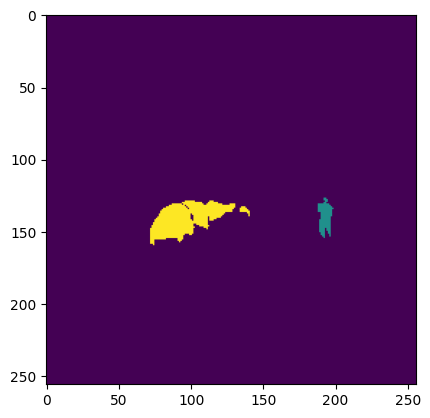

In [12]:
mask = np.zeros(
    (training_image["height"], training_image["width"]),
    dtype=np.uint8
)

for ann in training_image_annotations:

    object_category = get_category_name(
        ann["category_id"],
        categories
    )

    pixel_value = target_classes.index(object_category) + 1

    object_mask = coco.annToMask(ann)

    mask[object_mask == 1] = pixel_value

print(f"Unique pixel values in the mask: {np.unique(mask)}")

plt.imshow(mask)
plt.show()

# 1) Process towards Baseline model

In [13]:
# Helper function to check class distribution

def get_class_distribution(coco, target_classes):
    """
    Prints the number of unique images containing each target class.

    Args:
        coco: COCO object
        target_classes (list): List of class names
    """

    print("-" * 45)
    print(f"{'Class':<15}{'Images':>10}")
    print("-" * 45)

    class_distribution = {}

    for class_name in target_classes:

        # Get category ID
        cat_id = coco.getCatIds(catNms=[class_name])

        # Get image IDs containing this class
        img_ids = coco.getImgIds(catIds=cat_id)

        class_distribution[class_name] = len(img_ids)

        print(f"{class_name:<15}{len(img_ids):>10}")

    print("-" * 45)

    return class_distribution

In [14]:
target_classes = ["person", "car", "book", "airplane"]

class_distribution = get_class_distribution(coco, target_classes)

---------------------------------------------
Class              Images
---------------------------------------------
person                233
car                   148
book                   51
airplane                5
---------------------------------------------


### Since there is a clear classs imbalance lets check number of instances in each class and number of pixels each class holds

In [15]:
# Heler function to get number of instance
def get_object_distribution(coco, target_classes):
    """
    Count the total number of object instances for each target class.
    """

    print("-" * 50)
    print(f"{'Class':<15}{'Object Instances':>20}")
    print("-" * 50)

    object_distribution = {}

    for class_name in target_classes:

        cat_id = coco.getCatIds(catNms=[class_name])[0]

        ann_ids = coco.getAnnIds(catIds=[cat_id])

        object_distribution[class_name] = len(ann_ids)

        print(f"{class_name:<15}{len(ann_ids):>20}")

    print("-" * 50)

    return object_distribution

In [16]:
# Helper function to get number of instances
def get_pixel_distribution(coco, categories, target_classes, image_list):
    """
    Count the total number of pixels belonging to each class.
    """

    pixel_distribution = {cls: 0 for cls in target_classes}

    for image in image_list:

        ann_ids = coco.getAnnIds(imgIds=image["id"])
        anns = coco.loadAnns(ann_ids)

        for ann in anns:

            class_name = get_category_name(
                ann["category_id"],
                categories
            )

            if class_name in target_classes:

                mask = coco.annToMask(ann)

                pixel_distribution[class_name] += mask.sum()

    print("-" * 55)
    print(f"{'Class':<15}{'Total Pixels':>20}")
    print("-" * 55)

    for cls, pixels in pixel_distribution.items():
        print(f"{cls:<15}{pixels:>20,}")

    print("-" * 55)

    return pixel_distribution

In [17]:
target_classes = ["person", "car", "book", "airplane"]

# Class
class_distribution = get_class_distribution(coco, target_classes)

# Object
object_distribution = get_object_distribution(coco, target_classes)

# Pixels
pixel_distribution = get_pixel_distribution(
    coco,
    categories,
    target_classes,
    unique_training_images
)

---------------------------------------------
Class              Images
---------------------------------------------
person                233
car                   148
book                   51
airplane                5
---------------------------------------------
--------------------------------------------------
Class              Object Instances
--------------------------------------------------
person                         1084
car                             689
book                            155
airplane                         13
--------------------------------------------------
-------------------------------------------------------
Class                  Total Pixels
-------------------------------------------------------
person                    3,460,166
car                       2,111,519
book                        266,028
airplane                    113,628
-------------------------------------------------------


In [18]:
# Helper function to Resizing the image with black padding
def resize_with_padding(image, target_size=(512, 512), is_mask=False):
    """
    Resize image while maintaining aspect ratio,
    then pad to target size.

    Parameters
    ----------
    image : ndarray
    target_size : tuple (width, height)
    is_mask : bool
        True for segmentation masks.

    Returns
    -------
    padded_image
    """

    target_w, target_h = target_size

    h, w = image.shape[:2]

    # Scale factor
    scale = min(target_w / w, target_h / h)

    new_w = int(w * scale)
    new_h = int(h * scale)

    # Choose interpolation
    interpolation = (
        cv2.INTER_NEAREST if is_mask
        else cv2.INTER_LINEAR
    )

    resized = cv2.resize(
        image,
        (new_w, new_h),
        interpolation=interpolation
    )

    # Create blank canvas
    if len(image.shape) == 3:

        canvas = np.zeros(
            (target_h, target_w, 3),
            dtype=image.dtype
        )

    else:

        canvas = np.zeros(
            (target_h, target_w),
            dtype=image.dtype
        )

    # Center image
    x_offset = (target_w - new_w) // 2
    y_offset = (target_h - new_h) // 2

    canvas[
        y_offset:y_offset + new_h,
        x_offset:x_offset + new_w
    ] = resized

    return canvas

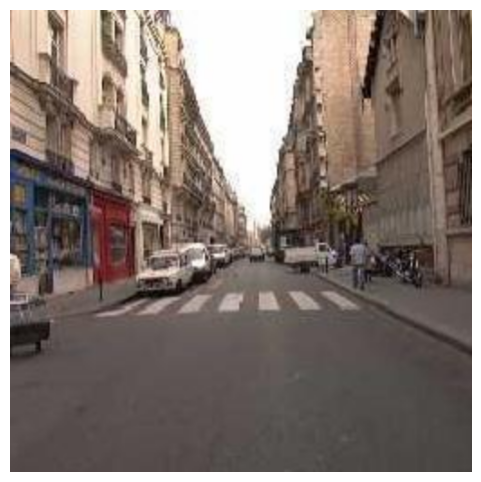

(512, 512, 3)


In [19]:
resized_image = resize_with_padding(
    image,
    target_size=(512, 512),
    is_mask=False
)

plt.figure(figsize=(6,6))
plt.imshow(resized_image)
plt.axis("off")
plt.show()

print(resized_image.shape)

In [20]:
# Helper function to normalize
def normalize_image(image):
    """
    Normalize image to [0,1].

    Parameters
    ----------
    image : ndarray

    Returns
    -------
    image : ndarray
    """

    image = image.astype(np.float32)
    image /= 255.0

    return image

In [21]:
normalized_image = normalize_image(resized_image)

print(normalized_image.dtype)
print(normalized_image.min())
print(normalized_image.max())

float32
0.0
1.0


In [22]:
# Helper function to convert data to tensor
def to_tensor(image, mask):
    """
    Convert image and mask to PyTorch tensors.
    """

    # HWC -> CHW
    image = np.transpose(image, (2, 0, 1))

    image = torch.tensor(image, dtype=torch.float32)
    mask = torch.tensor(mask, dtype=torch.long)

    return image, mask

In [23]:
image_tensor, mask_tensor = to_tensor(
    normalized_image,
    mask
)

print(image_tensor.shape)
print(mask_tensor.shape)

print(image_tensor.dtype)
print(mask_tensor.dtype)

torch.Size([3, 512, 512])
torch.Size([256, 256])
torch.float32
torch.int64


In [24]:
print(torch.unique(mask_tensor))

tensor([0, 1, 2])


## Custom dataset that doess the perprocesisng steps given above on all 350 image

In [25]:
class ADE20KDataset(Dataset):

    def __init__(           # Note that this is resulable class and the constructure (__init__) is present so the class is callable
        self,               # THis resuable code will be helpfull in a pipeline
        coco,
        image_list,
        image_path,
        categories,
        target_classes,
        image_size=(512, 512)
    ):

        self.coco = coco
        self.image_list = image_list
        self.image_path = image_path
        self.categories = categories
        self.target_classes = target_classes
        self.image_size = image_size


    def __len__(self):

        return len(self.image_list)


    def __getitem__(self, index):

        # ------------------------
        # Image Information
        # ------------------------
        image_info = self.image_list[index]

        # ------------------------
        # Load Image
        # ------------------------
        image = io.imread(
            f"{self.image_path}/{image_info['file_name']}"
        )

        # ------------------------
        # Load Annotations
        # ------------------------
        ann_ids = self.coco.getAnnIds(
            imgIds=image_info["id"]
        )

        annotations = self.coco.loadAnns(ann_ids)

        # ------------------------
        # Create Empty Mask
        # ------------------------
        mask = np.zeros(
            (image_info["height"], image_info["width"]),
            dtype=np.uint8
        )

        # ------------------------
        # Fill Mask
        # ------------------------
        for ann in annotations:

            class_name = get_category_name(
                ann["category_id"],
                self.categories
            )

            if class_name in self.target_classes:

                pixel_value = (
                    self.target_classes.index(class_name)
                    + 1
                )

                object_mask = self.coco.annToMask(ann)

                mask[object_mask == 1] = pixel_value

        # ------------------------
        # Resize
        # ------------------------
        image = resize_with_padding(
            image,
            self.image_size,
            is_mask=False
        )

        mask = resize_with_padding(
            mask,
            self.image_size,
            is_mask=True
        )

        # ------------------------
        # Normalize
        # ------------------------
        image = normalize_image(image)

        # ------------------------
        # Tensor
        # ------------------------
        image, mask = to_tensor(
            image,
            mask
        )

        return image, mask

In [26]:
# Run the class
train_dataset = ADE20KDataset(
    coco=coco,
    image_list=unique_training_images,
    image_path=train_data_path,
    categories=categories,
    target_classes=target_classes,
    image_size=(512, 512)
)

In [27]:
# Test to see if works
image, mask = train_dataset[0]

print(image.shape)
print(mask.shape)

print(torch.unique(mask))

torch.Size([3, 512, 512])
torch.Size([512, 512])
tensor([0, 1])


In [28]:
# Creating a train folder
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=2,        # Hyperparameter
    shuffle=True,
    num_workers=0
)

In [29]:
# Dataloader test
images, masks = next(iter(train_loader))

print(images.shape)
print(masks.shape)

print(images.dtype)
print(masks.dtype)

torch.Size([2, 3, 512, 512])
torch.Size([2, 512, 512])
torch.float32
torch.int64


# Transfer learning baseline model -- Vanilla U-net

In [30]:
# Double convolution bllock
import torch
import torch.nn as nn


class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):               # Resuable code with constructure for future uses.

        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):

        return self.conv(x)

In [31]:
# Down block
class Down(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.down = nn.Sequential(

            nn.MaxPool2d(kernel_size=2),

            DoubleConv(
                in_channels,
                out_channels
            )

        )

    def forward(self, x):

        return self.down(x)

In [32]:
# Up block
class Up(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.up = nn.Upsample(
            scale_factor=2,
            mode="bilinear",
            align_corners=True
        )

        self.conv = DoubleConv(
            in_channels,
            out_channels
        )


    def forward(self, x1, x2):

        # x1 = decoder feature
        x1 = self.up(x1)

        # concatenate with encoder feature
        x = torch.cat([x2, x1], dim=1)

        return self.conv(x)

In [33]:
# Feeature maps to class predictions
class OutConv(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.conv = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=1
        )

    def forward(self, x):

        return self.conv(x)

In [34]:
# Complete U-NET
class UNet(nn.Module):

    def __init__(self, n_channels=3, n_classes=5):

        super().__init__()

        # Encoder
        self.inc = DoubleConv(n_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        self.down4 = Down(512, 1024)

        # Decoder
        self.up1 = Up(1024 + 512, 512)
        self.up2 = Up(512 + 256, 256)
        self.up3 = Up(256 + 128, 128)
        self.up4 = Up(128 + 64, 64)

        # Output
        self.outc = OutConv(64, n_classes)


    def forward(self, x):

        # Encoder
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        # Decoder
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)

        # Output
        logits = self.outc(x)

        return logits

In [60]:
# MOdel INIT
model = UNet(
    n_channels=3,
    n_classes=5
)

In [61]:
model = model.to(device)

In [62]:
def compute_class_weights(train_dataset, num_classes=5):

    pixel_counts = torch.zeros(num_classes)

    for _, mask in train_dataset:

        unique, counts = torch.unique(mask, return_counts=True)

        for cls, count in zip(unique, counts):

            pixel_counts[cls] += count

    print("Pixel Counts")
    print(pixel_counts)

    total_pixels = pixel_counts.sum()

    class_weights = total_pixels / (num_classes * pixel_counts)

    class_weights = class_weights / class_weights.sum() * num_classes

    return class_weights

In [63]:
class_weights = compute_class_weights(
    train_dataset,
    num_classes=5
)

print(class_weights)

Pixel Counts
tensor([8.7156e+07, 2.6816e+06, 1.5413e+06, 3.1536e+05, 5.5710e+04])
tensor([2.5895e-03, 8.4163e-02, 1.4642e-01, 7.1566e-01, 4.0512e+00])


In [69]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(device)
)
criterion = criterion.to(device)

In [70]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [71]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

In [72]:
# Training helper function
def train_one_epoch(
    model,
    dataloader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0

    for images, masks in dataloader:

        images = images.to(device)
        masks = masks.to(device)

        # -----------------------
        # Forward Pass
        # -----------------------
        outputs = model(images)

        # -----------------------
        # Compute Loss
        # -----------------------
        loss = criterion(
            outputs,
            masks
        )

        # -----------------------
        # Backpropagation
        # -----------------------
        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        # -----------------------
        # Running Loss
        # -----------------------
        running_loss += loss.item()

    epoch_loss = running_loss / len(dataloader)

    return epoch_loss

In [73]:
train_loss = train_one_epoch(
    model,
    train_loader,
    criterion,
    optimizer,
    device
)

print(f"Training Loss : {train_loss:.4f}")

Training Loss : 1.4275


In [79]:
val_data_path = "/content/drive/MyDrive/ADE20K/val"
val_annotation_file = "/content/drive/MyDrive/ADE20K/instances_val.json"

val_coco = COCO(val_annotation_file)

# Get validation images containing the target classes
validation_images = []
for class_name in target_classes:
    validation_images_categories = val_coco.getCatIds(catNms=class_name)
    validation_images_IDs = val_coco.getImgIds(catIds=validation_images_categories)
    validation_images += val_coco.loadImgs(validation_images_IDs)

unique_validation_images = []
for i in range(len(validation_images)):
    if validation_images[i] not in unique_validation_images:
        unique_validation_images.append(validation_images[i])


val_dataset = ADE20KDataset(
    coco=val_coco,
    image_list=unique_validation_images,
    image_path=val_data_path,
    categories=categories,
    target_classes=target_classes,
    image_size=(512,512)
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=0
)

loading annotations into memory...
Done (t=0.04s)
creating index...
index created!


In [80]:
def validate_one_epoch(
    model,
    dataloader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0

    with torch.no_grad():

        for images, masks in dataloader:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                masks
            )

            running_loss += loss.item()

    epoch_loss = running_loss / len(dataloader)

    return epoch_loss

In [81]:
val_loss = validate_one_epoch(
    model=model,
    dataloader=val_loader,
    criterion=criterion,
    device=device
)

print(f"Validation Loss : {val_loss:.4f}")

Validation Loss : 1.3970


In [82]:
def fit(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    device,
    epochs
):

    history = {
        "train_loss": [],
        "val_loss": []
    }

    for epoch in range(epochs):

        train_loss = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        val_loss = validate_one_epoch(
            model,
            val_loader,
            criterion,
            device
        )

        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"| Train Loss: {train_loss:.4f} "
            f"| Val Loss: {val_loss:.4f}"
        )

    return history

In [83]:
history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    epochs=10
)

Epoch [1/10] | Train Loss: 1.3563 | Val Loss: 1.3219
Epoch [2/10] | Train Loss: 1.3313 | Val Loss: 1.3486
Epoch [3/10] | Train Loss: 1.2990 | Val Loss: 1.2823
Epoch [4/10] | Train Loss: 1.2931 | Val Loss: 1.2952
Epoch [5/10] | Train Loss: 1.2863 | Val Loss: 1.2855
Epoch [6/10] | Train Loss: 1.2660 | Val Loss: 1.2538
Epoch [7/10] | Train Loss: 1.2975 | Val Loss: 1.3524
Epoch [8/10] | Train Loss: 1.2847 | Val Loss: 1.2447
Epoch [9/10] | Train Loss: 1.2474 | Val Loss: 1.2321
Epoch [10/10] | Train Loss: 1.2286 | Val Loss: 1.2306


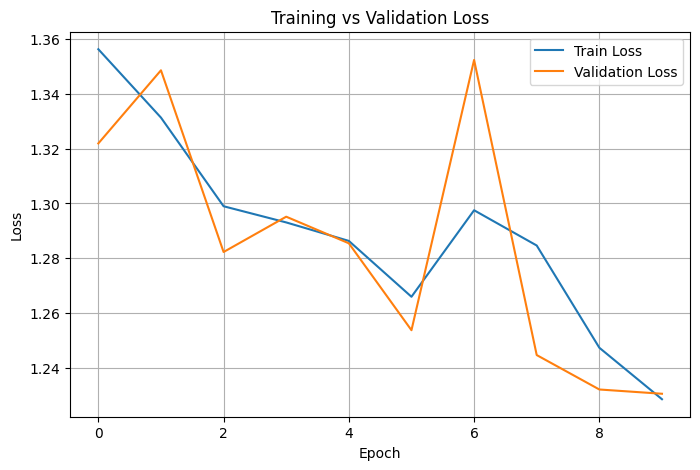

In [84]:
plt.figure(figsize=(8,5))

plt.plot(
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

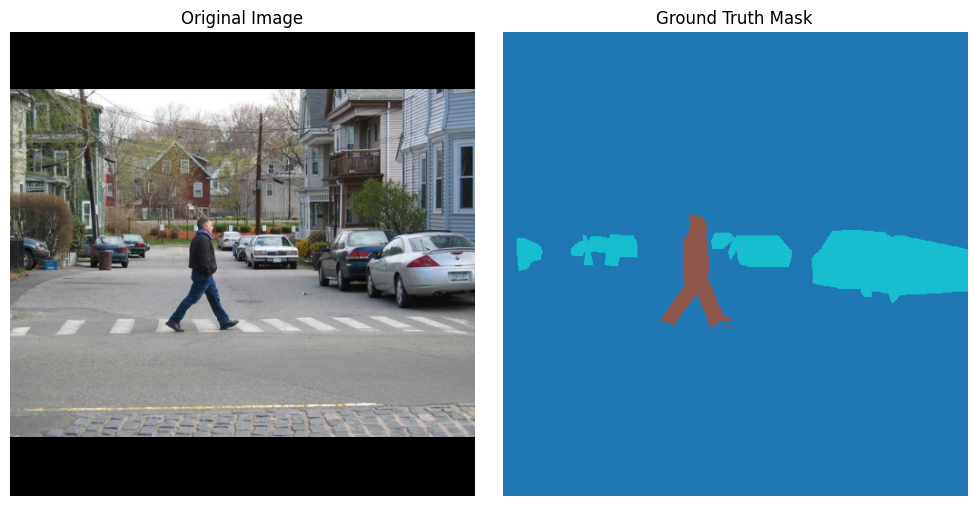

In [85]:
# Get one validation sample
image, mask = val_dataset[0]

# Convert image back to HWC format
image = image.permute(1, 2, 0).numpy()

# Convert mask to numpy
mask = mask.numpy()

plt.figure(figsize=(10,5))

# Original Image
plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

# Ground Truth
plt.subplot(1,2,2)
plt.imshow(mask, cmap="tab10")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

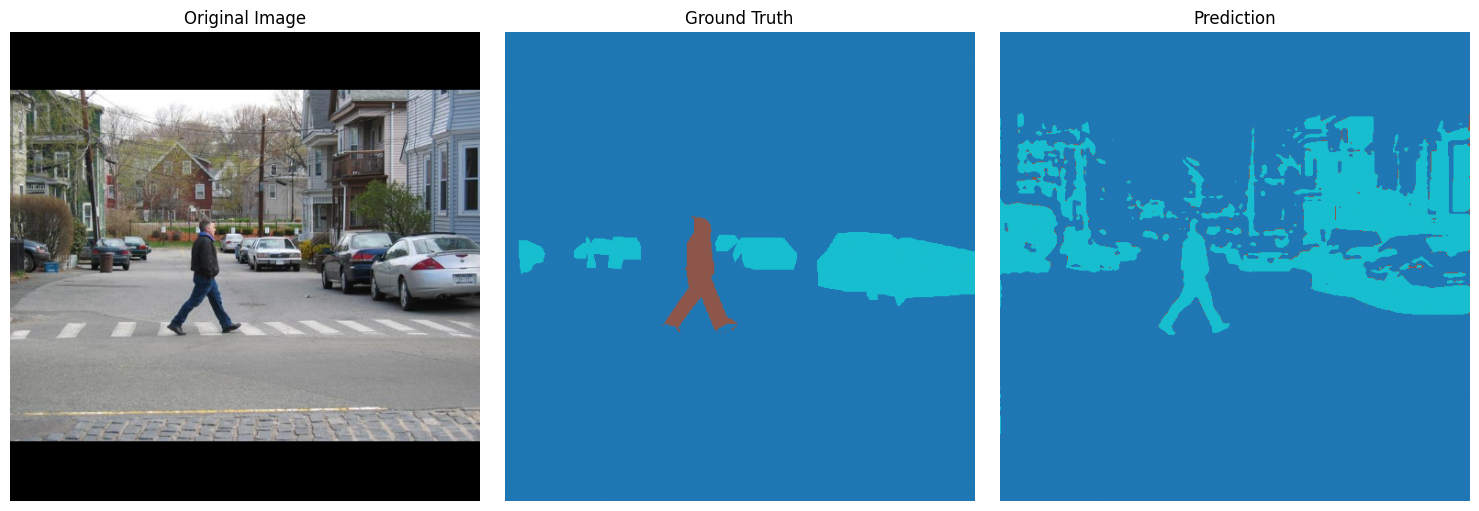

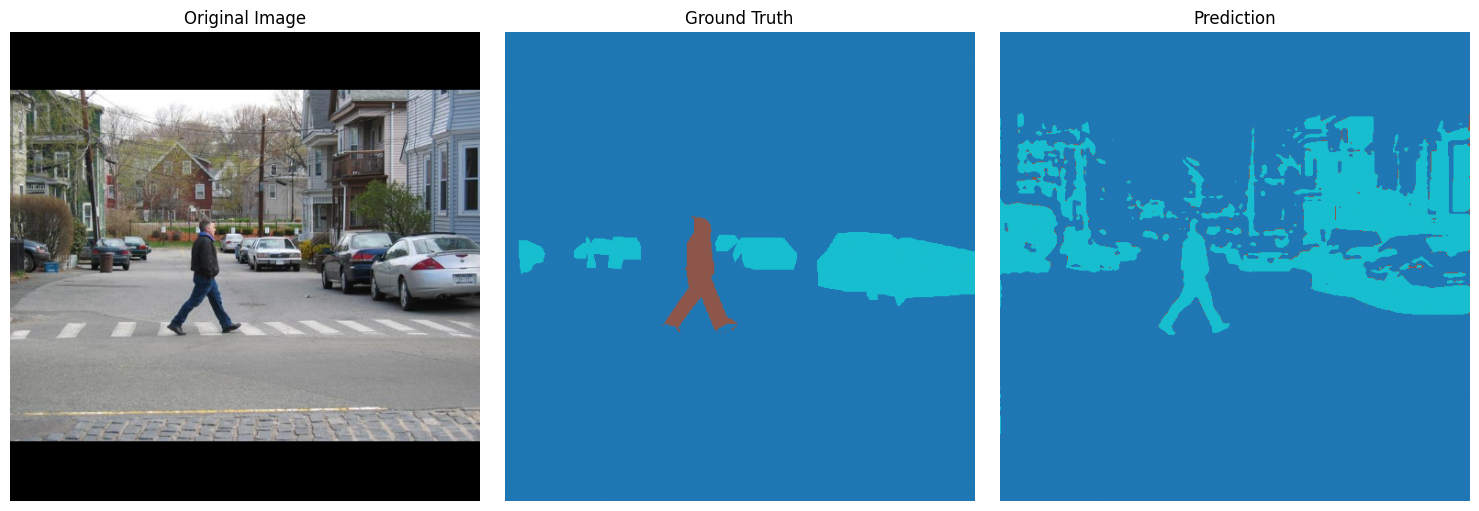

In [87]:
# Put model in evaluation mode
model.eval()

# Get one validation sample
image, mask = val_dataset[0]

# Add batch dimension
input_image = image.unsqueeze(0).to(device)

# Predict
with torch.no_grad():
    output = model(input_image)

prediction = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

# Convert image back for plotting
image = image.permute(1, 2, 0).numpy()

# Convert mask to numpy
mask = mask.numpy()

# Plot
plt.figure(figsize=(15,5))

# Original
plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

# Ground Truth
plt.subplot(1,3,2)
plt.imshow(mask, cmap="tab10")
plt.title("Ground Truth")
plt.axis("off")

# Prediction
plt.subplot(1,3,3)
plt.imshow(prediction, cmap="tab10")
plt.title("Prediction")
plt.axis("off")

plt.tight_layout()
plt.show()# Put model in evaluation mode
model.eval()

# Get one validation sample
image, mask = val_dataset[0]

# Add batch dimension
input_image = image.unsqueeze(0).to(device)

# Predict
with torch.no_grad():
    output = model(input_image)

prediction = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

# Convert image back for plotting
image = image.permute(1, 2, 0).numpy()

# Convert mask to numpy
mask = mask.numpy()

# Plot
plt.figure(figsize=(15,5))

# Original
plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

# Ground Truth
plt.subplot(1,3,2)
plt.imshow(mask, cmap="tab10")
plt.title("Ground Truth")
plt.axis("off")

# Prediction
plt.subplot(1,3,3)
plt.imshow(prediction, cmap="tab10")
plt.title("Prediction")
plt.axis("off")

plt.tight_layout()
plt.show()

In [88]:
print("Ground Truth Classes :", np.unique(mask))
print("Predicted Classes   :", np.unique(prediction))

Ground Truth Classes : [0 1 2]
Predicted Classes   : [0 1 2]


In [89]:
# Find first validation image containing an airplane

for idx in range(len(val_dataset)):

    image, mask = val_dataset[idx]

    if 4 in torch.unique(mask):

        print(f"Airplane found in image index: {idx}")

        break

Airplane found in image index: 86


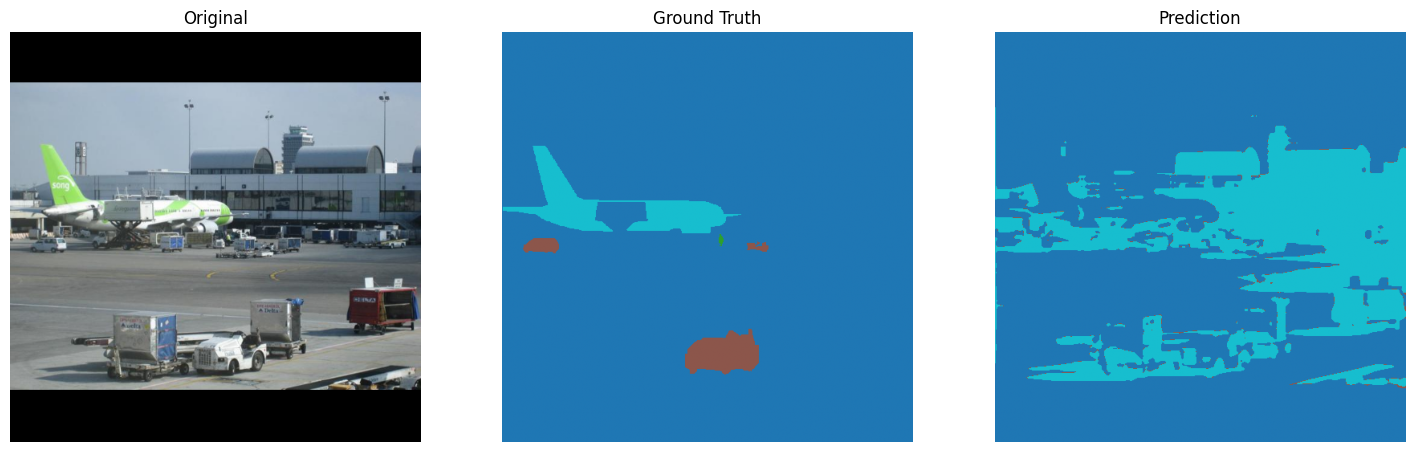

Ground Truth: [0 1 2 4]
Prediction  : [0 1 2]


In [90]:
model.eval()

image, mask = val_dataset[86]

input_image = image.unsqueeze(0).to(device)

with torch.no_grad():
    output = model(input_image)

prediction = torch.argmax(output, dim=1).squeeze().cpu().numpy()

image = image.permute(1,2,0).numpy()
mask = mask.numpy()

plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask, cmap="tab10")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(prediction, cmap="tab10")
plt.title("Prediction")
plt.axis("off")

plt.show()

print("Ground Truth:", np.unique(mask))
print("Prediction  :", np.unique(prediction))